In [1]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

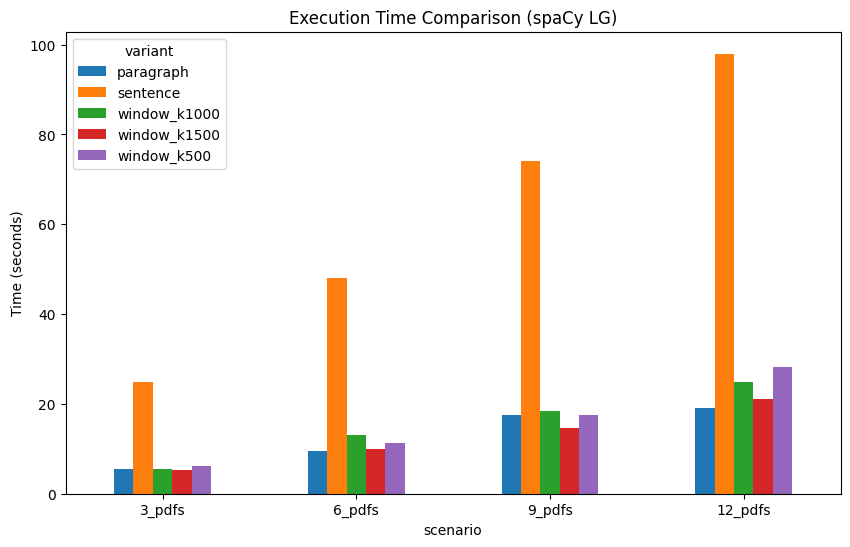

In [8]:
# 1. Criar coluna de ordenação numérica
df_perf['order'] = df_perf['scenario'].str.extract(r'(\d+)').astype(int)

# 2. Ordenar o dataframe e pegar a lista de cenários na ordem certa
df_perf = df_perf.sort_values('order')
ordem_correta = df_perf['scenario'].unique()

# 3. Fazer o pivot e aplicar o reindex antes de plotar
df_pivot_perf = df_perf.pivot(index='scenario', columns='variant', values='total_time_sec')
df_pivot_perf = df_pivot_perf.reindex(ordem_correta)

# 4. Plotar
df_pivot_perf.plot(kind='bar', figsize=(10, 6))
plt.title("Execution Time Comparison (spaCy LG)")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0) # Deixa o texto do eixo X na horizontal
plt.show()

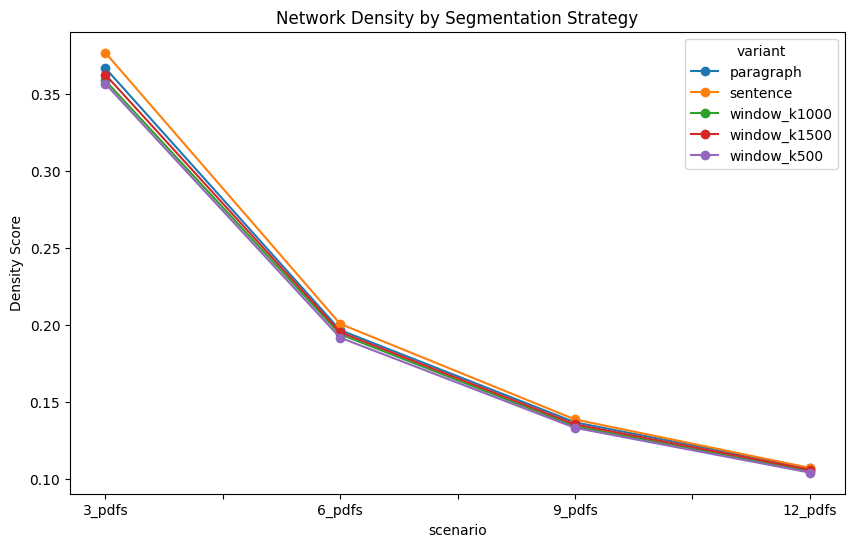

In [9]:
# 1. Criar coluna de ordenação e ordenar dataframe
df_metrics['order'] = df_metrics['scenario'].str.extract(r'(\d+)').astype(int)
df_metrics = df_metrics.sort_values('order')
ordem_correta_metrics = df_metrics['scenario'].unique()

# 2. Pivot e Reindex
df_pivot_metrics = df_metrics.pivot(index='scenario', columns='variant', values='density')
df_pivot_metrics = df_pivot_metrics.reindex(ordem_correta_metrics)

# 3. Plotar
df_pivot_metrics.plot(kind='line', marker='o', figsize=(10, 6))
plt.title("Network Density by Segmentation Strategy")
plt.ylabel("Density Score")
plt.show()

In [11]:
# Load one of your GML graphs
graph_path = Path("../data/graphs/graph_6_pdfs_sentence.gml")
G = nx.read_gml(graph_path)

# Calculate centrality
centrality = nx.degree_centrality(G)
top_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 Entities by Degree Centrality:")
for node, val in top_nodes:
    print(f"{node}: {val:.4f}")

Top 10 Entities by Degree Centrality:
UFRN: 0.9635
Natal: 0.9635
Prof: 0.9635
Universidade Federal do Rio Grande do Norte: 0.9635
Figura: 0.9635
RESULTADOS: 0.8752
Sistema de Bibliotecas: 0.8738
SISBI: 0.8738
Catalogação de Publicação na Fonte: 0.8738
Python: 0.8397
